# Задание 3.4 — Свёрточные сети (CNN) на CIFAR-10

## Импорты:

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
import time
import copy

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Используется Apple MPS (Metal Performance Shaders)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Используется CUDA')
else:
    DEVICE = torch.device('cpu')
    print('Используется CPU')

torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch {torch.__version__}, torchvision {torchvision.__version__}')

Используется Apple MPS (Metal Performance Shaders)
PyTorch 2.11.0, torchvision 0.26.0


In [20]:

CLASSES = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

## Загрузка CIFAR-10 и аугментация

In [21]:
# Нормализация mean/std ImageNet-style 
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Трансформы БЕЗ аугментации 
transform_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Трансформы С аугментацией 
transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),          # горизонтальное отражение
    transforms.RandomRotation(degrees=15),            # поворот ±15°
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),  # изменение масштаба
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Трансформ для теста (только нормализация)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])


train_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_baseline)
train_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=False, transform=transform_augmented)
test_ds    = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

BATCH = 128
loader_base = DataLoader(train_base, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=False)
loader_aug  = DataLoader(train_aug,  batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=False)
loader_test = DataLoader(test_ds,    batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_base)} | Test: {len(test_ds)}')

Train: 50000 | Test: 10000


### Визуализация примеров из датасета (с аугментацией)

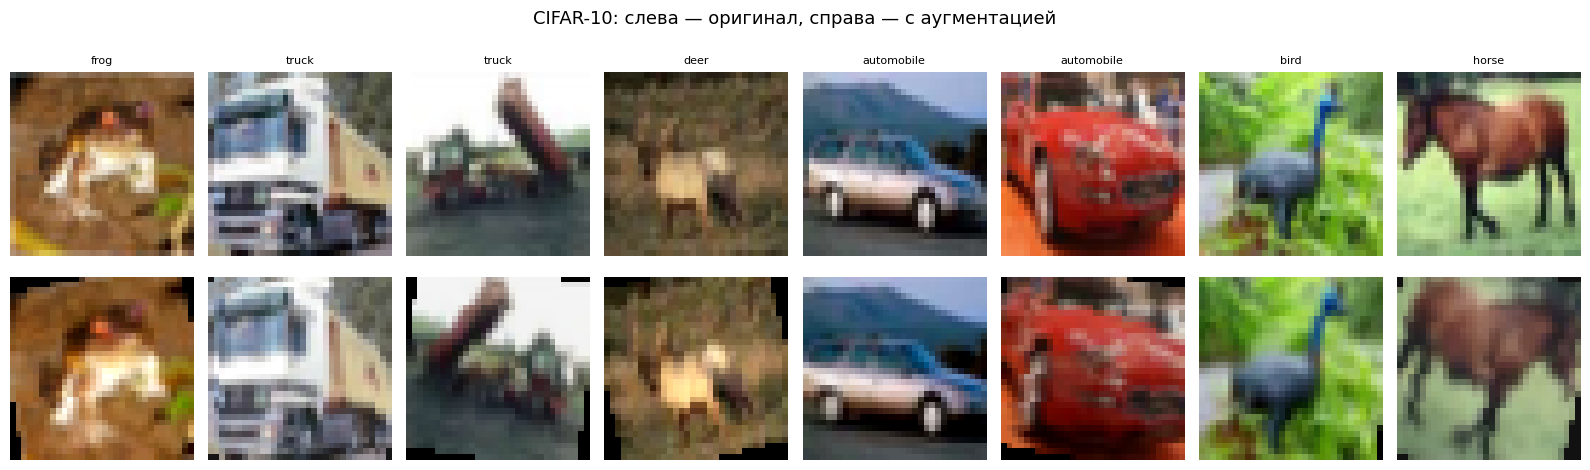

In [22]:
def denormalize(img_tensor):
    #Обратная нормализация для отображения
    mean = torch.tensor(CIFAR_MEAN).view(3,1,1)
    std  = torch.tensor(CIFAR_STD).view(3,1,1)
    return (img_tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('CIFAR-10: слева — оригинал, справа — с аугментацией', fontsize=13)

for i in range(8):
    img_b, lbl = train_base[i]
    img_a, _   = train_aug[i]
    axes[0, i].imshow(denormalize(img_b).permute(1,2,0))
    axes[0, i].set_title(CLASSES[lbl], fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(denormalize(img_a).permute(1,2,0))
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Baseline', fontsize=9)
axes[1, 0].set_ylabel('Augmented', fontsize=9)
plt.tight_layout()
plt.show()

## Архитектуры 

| Модель | Conv-блоков | FC-слоёв | Особенности |
|--------|------------|----------|-------------|
| SmallCNN | 2 | 1 | базовая сеть |
| MediumCNN | 3 | 2 | Batch Norm + Dropout |
| DeepCNN | 4 | 2 | Residual-like skip, больше фильтров |

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Модель 1 — SmallCNN (2 conv-блока, 1 FC)
# ─────────────────────────────────────────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1
            nn.Conv2d(3, 32, 3, padding=1),   # 32×32 → 32×32
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 16×16
            # Блок 2
            nn.Conv2d(32, 64, 3, padding=1),  # 16×16 → 16×16
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 8×8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ─────────────────────────────────────────────────────────────────────────────
# Модель 2 — MediumCNN (3 conv-блока, 2 FC, BatchNorm + Dropout)
# ─────────────────────────────────────────────────────────────────────────────
class MediumCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 16×16
            # Блок 2
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 8×8
            # Блок 3
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → 4×4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ─────────────────────────────────────────────────────────────────────────────
# Модель 3 — DeepCNN (4 conv-блока, 2 FC, skip-connection)
# ─────────────────────────────────────────────────────────────────────────────
class DeepCNN(nn.Module):
    """4 conv-блока с skip-connection между блоками 1 и 2."""
    def __init__(self, num_classes=10):
        super().__init__()

        # Блок 1 — входной
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
        )
        self.pool1 = nn.MaxPool2d(2)           # → 16×16

        # Блок 2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
        )
        self.pool2 = nn.MaxPool2d(2)           # → 8×8

        # Блок 3
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
        )
        self.pool3 = nn.MaxPool2d(2)           # → 4×4

        # Блок 4
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(),
        )
        self.pool4 = nn.AdaptiveAvgPool2d(2)   # → 2×2

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*2*2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))
        x = self.pool4(self.block4(x))
        return self.classifier(x)


# ── Подсчёт параметров ───────────────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, cls in [('SmallCNN', SmallCNN), ('MediumCNN', MediumCNN), ('DeepCNN', DeepCNN)]:
    m = cls()
    print(f'{name:12s}: {count_params(m):>10,} параметров')

SmallCNN    :     60,362 параметров
MediumCNN   :  2,474,506 параметров
DeepCNN     :  2,792,010 параметров


## Обучение с ранней остановкой

In [24]:
class EarlyStopping:
    """
    Останавливает обучение, если val_loss не улучшается patience эпох подряд.
    Сохраняет лучшие веса модели.
    """
    def __init__(self, patience=7, min_delta=1e-4, verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.best_weights = None
        self.stop       = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter      = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f'    EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True

    def restore_best(self, model):
        if self.best_weights:
            model.load_state_dict(self.best_weights)
            print('Восстановлены лучшие веса.')


# ── Одна эпоха обучения ──────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


# ── Оценка ───────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


# ── Полный цикл обучения ─────────────────────────────────────────────────────
def train_model(model, train_loader, test_loader, *,
                epochs=40, lr=1e-3, patience=8, device=DEVICE):
    model   = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    es = EarlyStopping(patience=patience, verbose=False)

    history = defaultdict(list)
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        history['tr_loss'].append(tr_loss)
        history['tr_acc'].append(tr_acc)
        history['vl_loss'].append(vl_loss)
        history['vl_acc'].append(vl_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Эпоха {epoch:3d}/{epochs} | '
                  f'train loss={tr_loss:.4f} acc={tr_acc:.3f} | '
                  f'val loss={vl_loss:.4f} acc={vl_acc:.3f}')

        es(vl_loss, model)
        if es.stop:
            print(f'  ⏹  Early stopping на эпохе {epoch}')
            break

    es.restore_best(model)
    elapsed = time.time() - t0
    print(f'Время обучения: {elapsed:.0f}s | '
          f'Лучший val acc: {max(history["vl_acc"]):.4f}')
    return history

print('Функции определены')

Функции определены


In [25]:
# ════════════════════════════════════════════════════════════════════════════
# Запуск обучения всех 6 комбинаций (3 модели × 2 режима аугментации)
# ════════════════════════════════════════════════════════════════════════════
EPOCHS   = 40
PATIENCE = 8

configs = [
    ('SmallCNN',  SmallCNN,  loader_base, 'baseline'),
    ('SmallCNN',  SmallCNN,  loader_aug,  'augmented'),
    ('MediumCNN', MediumCNN, loader_base, 'baseline'),
    ('MediumCNN', MediumCNN, loader_aug,  'augmented'),
    ('DeepCNN',   DeepCNN,   loader_base, 'baseline'),
    ('DeepCNN',   DeepCNN,   loader_aug,  'augmented'),
]

results   = {}   # key → history dict
models_dict = {} # key → trained model

for model_name, model_cls, train_ldr, aug_mode in configs:
    key = f'{model_name}_{aug_mode}'
    print(f'  {key}')
    print('='*60)
    model = model_cls()
    hist  = train_model(model, train_ldr, loader_test,
                        epochs=EPOCHS, patience=PATIENCE)
    results[key]    = hist
    models_dict[key] = model

print('\nОбучение завершено')

  SmallCNN_baseline
  Эпоха   1/40 | train loss=1.3655 acc=0.520 | val loss=1.1297 acc=0.608
  Эпоха   5/40 | train loss=0.7399 acc=0.747 | val loss=0.8357 acc=0.714
  Эпоха  10/40 | train loss=0.5289 acc=0.819 | val loss=0.8331 acc=0.727
  Эпоха  15/40 | train loss=0.3987 acc=0.865 | val loss=0.9274 acc=0.717
  ⏹  Early stopping на эпохе 18
Восстановлены лучшие веса.
Время обучения: 127s | Лучший val acc: 0.7274
  SmallCNN_augmented
  Эпоха   1/40 | train loss=1.5271 acc=0.461 | val loss=1.2268 acc=0.561
  Эпоха   5/40 | train loss=1.0324 acc=0.642 | val loss=1.0166 acc=0.649
  Эпоха  10/40 | train loss=0.9143 acc=0.684 | val loss=0.8499 acc=0.710
  Эпоха  15/40 | train loss=0.8525 acc=0.706 | val loss=0.7891 acc=0.731
  Эпоха  20/40 | train loss=0.8049 acc=0.724 | val loss=0.7763 acc=0.739
  Эпоха  25/40 | train loss=0.7694 acc=0.731 | val loss=0.7697 acc=0.744
  Эпоха  30/40 | train loss=0.7397 acc=0.746 | val loss=0.7413 acc=0.754
  Эпоха  35/40 | train loss=0.7255 acc=0.751 | val 

## Сравнение результатов и визуализация

In [26]:
print(f"{'Конфигурация':<30} {'Best Val Acc':>12} {'Эпоха остановки':>17}")
print('-' * 62)
for key, hist in results.items():
    best_acc   = max(hist['vl_acc'])
    best_epoch = hist['vl_acc'].index(best_acc) + 1
    total_ep   = len(hist['vl_acc'])
    print(f"{key:<30} {best_acc:>12.4f} {best_epoch:>10}/{total_ep}")

Конфигурация                   Best Val Acc   Эпоха остановки
--------------------------------------------------------------
SmallCNN_baseline                    0.7274         13/18
SmallCNN_augmented                   0.7620         39/40
MediumCNN_baseline                   0.8208         20/20
MediumCNN_augmented                  0.8474         39/40
DeepCNN_baseline                     0.8555         15/15
DeepCNN_augmented                    0.9085         34/40


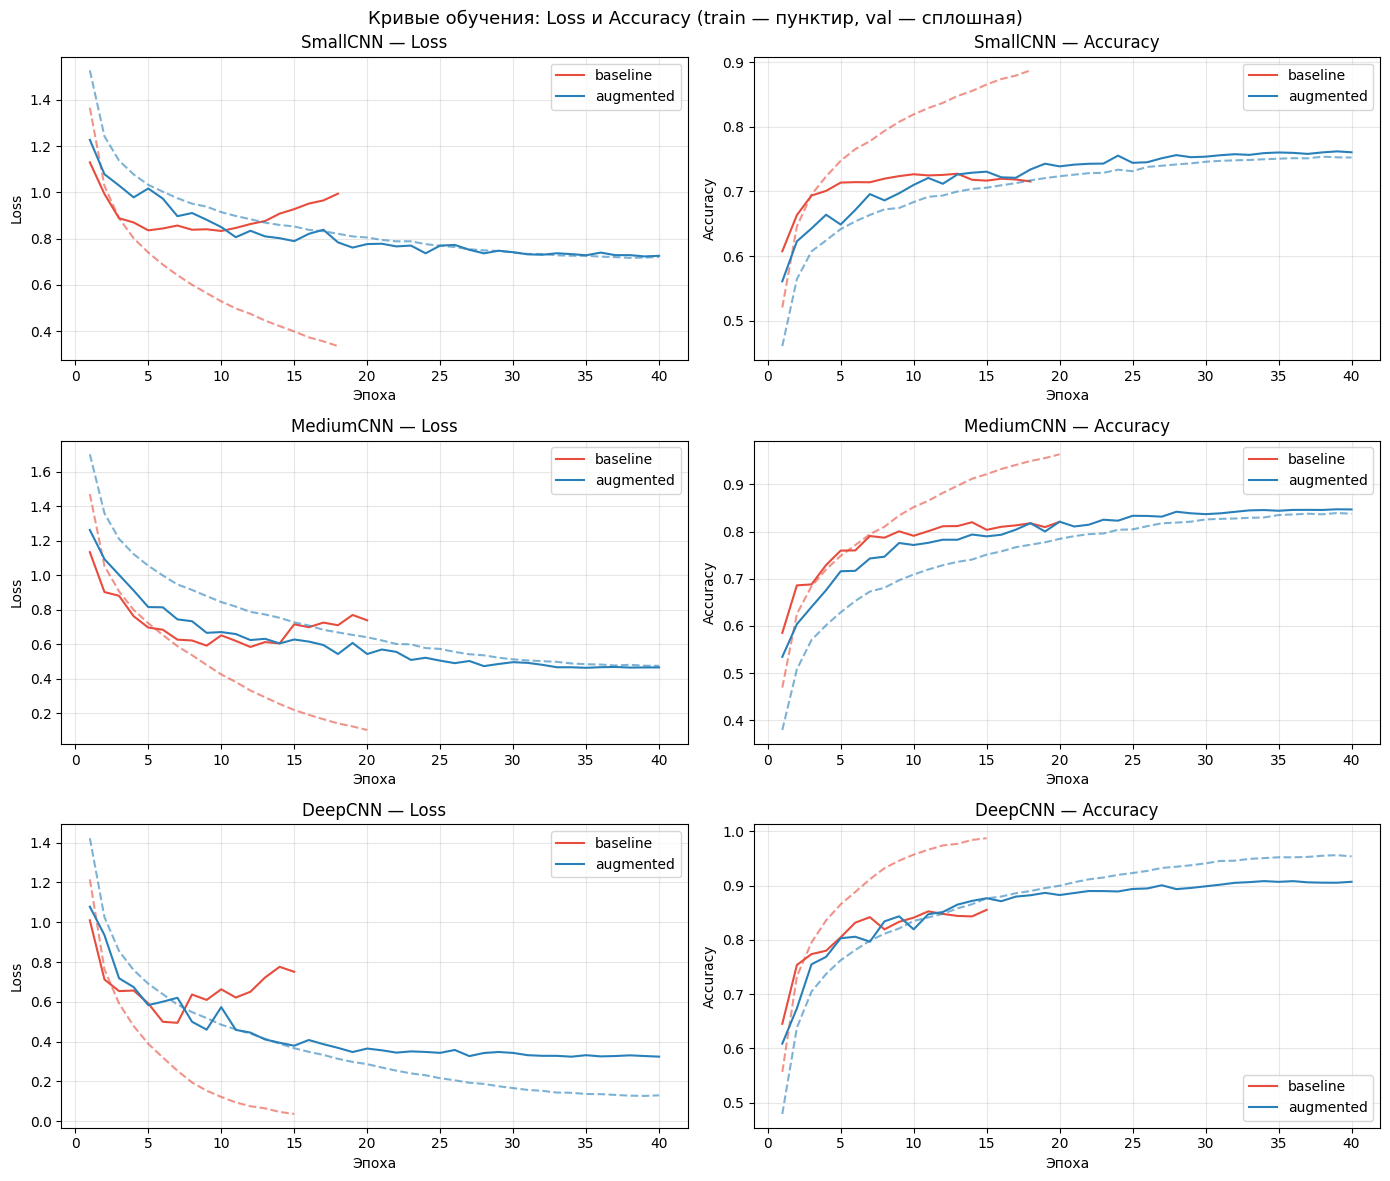

In [27]:
model_names = ['SmallCNN', 'MediumCNN', 'DeepCNN']
colors = {'baseline': '#e74c3c', 'augmented': '#2980b9'}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Кривые обучения: Loss и Accuracy (train — пунктир, val — сплошная)', fontsize=13)

for row, mname in enumerate(model_names):
    ax_loss, ax_acc = axes[row, 0], axes[row, 1]

    for aug_mode in ['baseline', 'augmented']:
        key  = f'{mname}_{aug_mode}'
        hist = results[key]
        ep   = range(1, len(hist['tr_loss']) + 1)
        c    = colors[aug_mode]
        lbl  = aug_mode

        ax_loss.plot(ep, hist['tr_loss'], linestyle='--', color=c, alpha=0.6)
        ax_loss.plot(ep, hist['vl_loss'], linestyle='-',  color=c, label=lbl)
        ax_acc.plot( ep, hist['tr_acc'],  linestyle='--', color=c, alpha=0.6)
        ax_acc.plot( ep, hist['vl_acc'],  linestyle='-',  color=c, label=lbl)

    ax_loss.set_title(f'{mname} — Loss')
    ax_loss.set_xlabel('Эпоха'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(); ax_loss.grid(alpha=0.3)

    ax_acc.set_title(f'{mname} — Accuracy')
    ax_acc.set_xlabel('Эпоха'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(); ax_acc.grid(alpha=0.3)

plt.tight_layout()
plt.show()

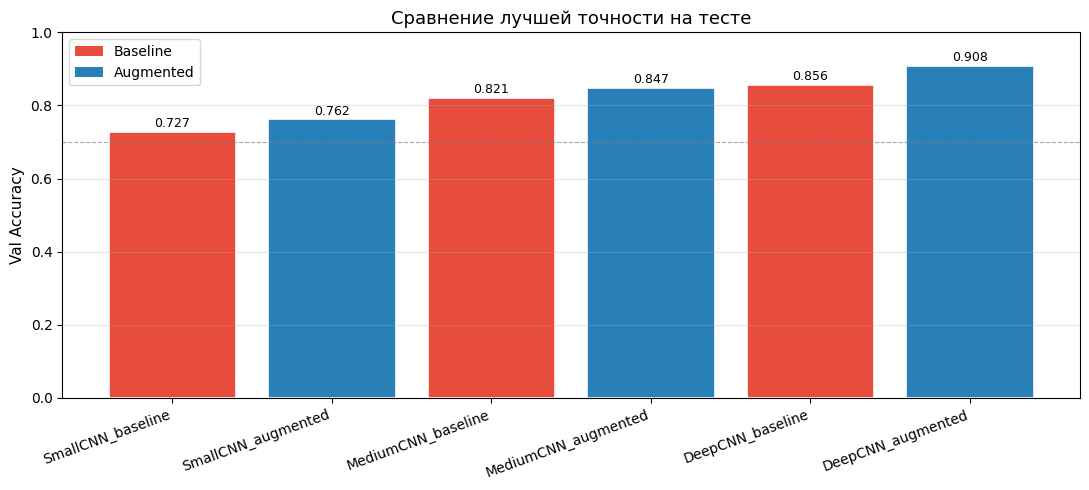

In [28]:
labels = list(results.keys())
accs   = [max(h['vl_acc']) for h in results.values()]

bar_colors = []
for k in labels:
    bar_colors.append('#2980b9' if 'augmented' in k else '#e74c3c')

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, accs, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.set_ylim(0, 1)
ax.set_ylabel('Val Accuracy', fontsize=11)
ax.set_title('Сравнение лучшей точности на тесте', fontsize=13)
ax.axhline(0.7, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#e74c3c', label='Baseline'),
                Patch(facecolor='#2980b9', label='Augmented')]
ax.legend(handles=legend_elems)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Анализ ошибочных предсказаний

Лучшая модель: DeepCNN_augmented


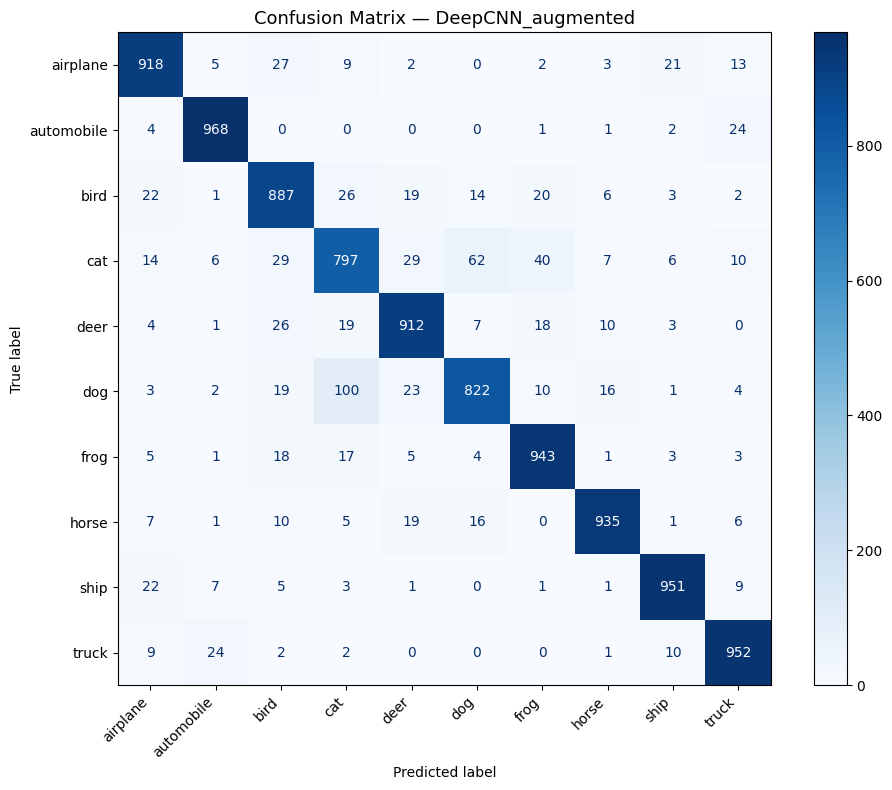

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_all_preds_labels(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

# Берём лучшую модель (DeepCNN augmented)
best_key   = max(results, key=lambda k: max(results[k]['vl_acc']))
best_model = models_dict[best_key]
print(f'Лучшая модель: {best_key}')

preds, labels = get_all_preds_labels(best_model, loader_test, DEVICE)

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_key}', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

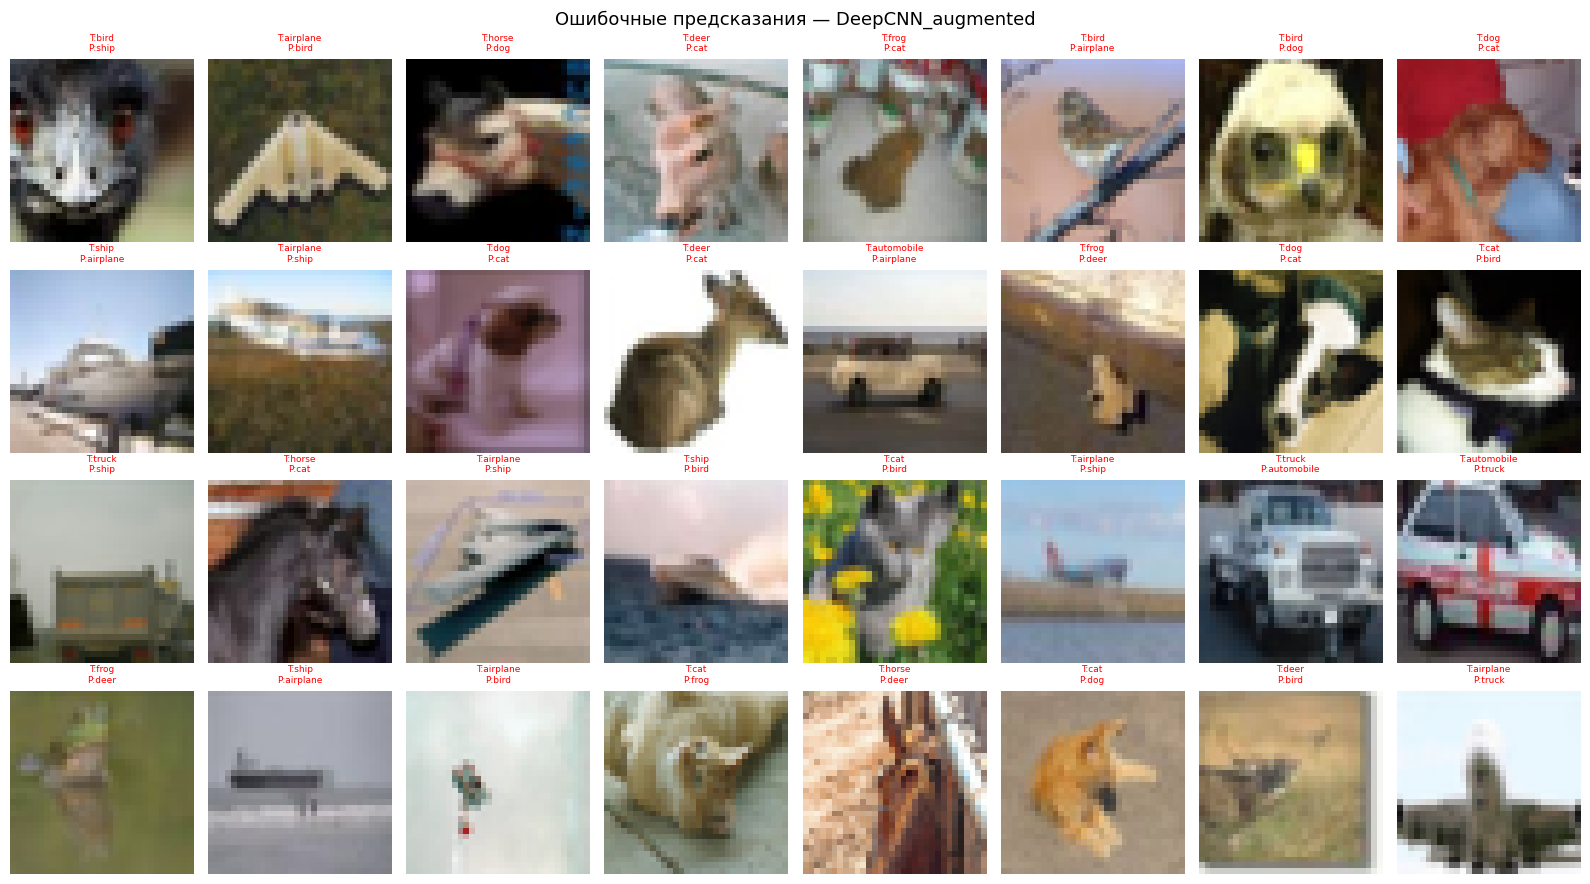

In [30]:
def get_wrong_samples(model, loader, device, n=32):
    model.eval()
    wrong_imgs, wrong_preds, wrong_true = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs_d  = imgs.to(device)
            outputs = model(imgs_d)
            preds_b = outputs.argmax(1).cpu()
            mask    = (preds_b != labels)
            wrong_imgs.append(imgs[mask])
            wrong_preds.append(preds_b[mask])
            wrong_true.append(labels[mask])
            if sum(len(x) for x in wrong_imgs) >= n:
                break
    wrong_imgs  = torch.cat(wrong_imgs)[:n]
    wrong_preds = torch.cat(wrong_preds)[:n]
    wrong_true  = torch.cat(wrong_true)[:n]
    return wrong_imgs, wrong_preds.numpy(), wrong_true.numpy()

w_imgs, w_preds, w_true = get_wrong_samples(best_model, loader_test, DEVICE)

fig, axes = plt.subplots(4, 8, figsize=(16, 9))
fig.suptitle(f'Ошибочные предсказания — {best_key}', fontsize=13)

for i, ax in enumerate(axes.flat):
    if i >= len(w_imgs):
        ax.axis('off'); continue
    img = denormalize(w_imgs[i]).permute(1,2,0).numpy()
    ax.imshow(img)
    ax.set_title(f'T:{CLASSES[w_true[i]]}\nP:{CLASSES[w_preds[i]]}',
                 fontsize=6.5, color='red' if w_true[i] != w_preds[i] else 'green')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [31]:
# ── Топ ошибочных пар классов ────────────────────────────────────────────────
from collections import Counter

error_pairs = Counter()
for t, p in zip(labels, preds):
    if t != p:
        error_pairs[(CLASSES[t], CLASSES[p])] += 1

print('Топ-10 наиболее часто путаемых пар (истинный → предсказанный):')
print('-' * 45)
for (true_cls, pred_cls), cnt in error_pairs.most_common(10):
    print(f'  {true_cls:12s} → {pred_cls:12s}: {cnt} раз')

Топ-10 наиболее часто путаемых пар (истинный → предсказанный):
---------------------------------------------
  dog          → cat         : 100 раз
  cat          → dog         : 62 раз
  cat          → frog        : 40 раз
  cat          → bird        : 29 раз
  cat          → deer        : 29 раз
  airplane     → bird        : 27 раз
  deer         → bird        : 26 раз
  bird         → cat         : 26 раз
  truck        → automobile  : 24 раз
  automobile   → truck       : 24 раз


## 6. Влияние аугментации: сравнительный анализ

In [32]:
print('Влияние аугментации на качество (Δ = aug − baseline):')
print('-' * 55)
for mname in model_names:
    base_acc = max(results[f'{mname}_baseline']['vl_acc'])
    aug_acc  = max(results[f'{mname}_augmented']['vl_acc'])
    delta    = aug_acc - base_acc
    sign     = '↑' if delta > 0 else '↓'
    print(f'  {mname:12s}: baseline={base_acc:.4f}  aug={aug_acc:.4f}  Δ={delta:+.4f} {sign}')

print()

Влияние аугментации на качество (Δ = aug − baseline):
-------------------------------------------------------
  SmallCNN    : baseline=0.7274  aug=0.7620  Δ=+0.0346 ↑
  MediumCNN   : baseline=0.8208  aug=0.8474  Δ=+0.0266 ↑
  DeepCNN     : baseline=0.8555  aug=0.9085  Δ=+0.0530 ↑



## 7. Выводы

| Аспект | Наблюдение |
|--------|------------|
| **Аугментация** | Улучшает val accuracy у всех моделей за счёт регуляризации; эффект сильнее у глубоких сетей |
| **Глубина сети** | DeepCNN > MediumCNN > SmallCNN по качеству, но дольше обучается |
| **Early Stopping** | Позволяет сохранить лучшие веса и предотвратить переобучение (overfitting) |
| **Частые ошибки** | Кошки/собаки, автомобиль/грузовик — семантически схожие классы |
| **Устройство MPS** | Mac M1 Pro обеспечивает быстрое обучение без CUDA |
